<a href="https://colab.research.google.com/github/arshdeepverma/subscription-conversion-prediction/blob/main/Subscription_Conversion_Prediction_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Subscription Conversion Prediction — End-to-End ML Project

## Business Problem
A subscription-based app has many free users, but only a portion of them convert to paid subscriptions. The business wants to **predict which free users are likely to become paid customers** using their engagement behavior.

This can help the business:
- Identify high-potential free users
- Prioritize conversion campaigns
- Personalize offers and messaging
- Improve marketing efficiency
- Understand which engagement signals are associated with conversion

## Machine Learning Problem
This is a **supervised binary classification** problem.

### Target Variable
`Converted`

- `1` → User became a paid subscriber
- `0` → User did not become a paid subscriber

### Input Features
- Age
- Days since signup
- Sessions
- Visits
- Features used
- Average session duration
- Trial days used
- Support interactions

## Models Used
We will train and compare three classification algorithms:

1. **Logistic Regression** — interpretable linear baseline
2. **Decision Tree Classifier** — captures non-linear decision rules
3. **Random Forest Classifier** — ensemble of multiple decision trees

## Evaluation Metrics
Models will be compared using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## Final Architecture

```text
Raw User Data
      ↓
Data Cleaning
      ↓
EDA
      ↓
Feature Engineering
      ↓
Train / Test Split
      ↓
 ┌────────────────────────────┐
 │ Logistic Regression        │
 │ Decision Tree              │
 │ Random Forest              │
 └────────────────────────────┘
      ↓
Model Evaluation
      ↓
Accuracy | Precision | Recall
F1 | ROC-AUC | Confusion Matrix
      ↓
Select / Tune Model
      ↓
Predict Conversion Probability
```


## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)


## 2. Load Dataset

Upload `subscription_conversion_100_users.csv` to Colab, then run the next cell.

In [24]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())


Saving subscription_conversion_100_users.csv to subscription_conversion_100_users (1).csv
Dataset shape: (100, 10)


,User_ID,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted
0,U001,46,107,8,9,4,8.7,20,1,0
1,U002,32,137,10,13,4,14.2,26,3,1
2,U003,25,7,7,18,4,12.4,4,3,0
3,U004,38,11,15,9,2,13.5,0,1,0
4,U005,36,148,11,16,8,12.9,16,1,1


## 3. Understand the Dataset

In [25]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing_Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Converted"].value_counts().rename({0: "Not Converted", 1: "Converted"}))


Shape: (100, 10)

Data types:
User_ID                  object
Age                       int64
Days_Since_Signup         int64
Sessions                  int64
Visits                    int64
Features_Used             int64
Avg_Session_Minutes     float64
Trial_Days_Used           int64
Support_Interactions      int64
Converted                 int64
dtype: object

Missing values:


,Missing_Values
User_ID,0
Age,0
Days_Since_Signup,0
Sessions,0
Visits,0
Features_Used,0
Avg_Session_Minutes,0
Trial_Days_Used,0
Support_Interactions,0
Converted,0



Duplicate rows: 0

Target distribution:


,count
Converted,
Converted,55
Not Converted,45


## 4. Data Cleaning

In [26]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Handle missing numerical values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Shape after cleaning:", df.shape)
print("Total missing values:", df.isnull().sum().sum())


Shape after cleaning: (100, 10)
Total missing values: 0


## 5. Exploratory Data Analysis (EDA)

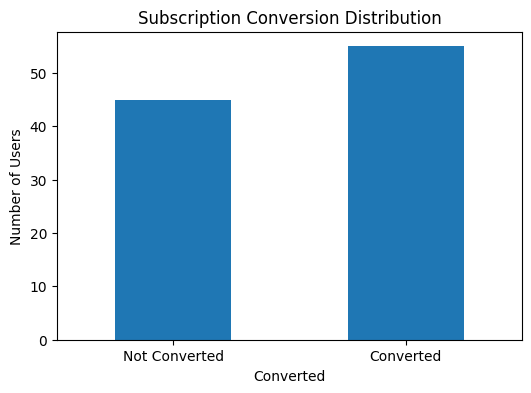

In [27]:
# Target distribution
plt.figure(figsize=(6, 4))
df["Converted"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Not Converted", "Converted"], rotation=0)
plt.ylabel("Number of Users")
plt.title("Subscription Conversion Distribution")
plt.show()


In [28]:
# Compare average engagement metrics by conversion
eda_cols = [
    "Sessions",
    "Visits",
    "Features_Used",
    "Avg_Session_Minutes",
    "Trial_Days_Used",
    "Support_Interactions"
]

display(df.groupby("Converted")[eda_cols].mean().round(2))


,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions
Converted,,,,,,
0,10.42,14.60,4.27,12.93,11.82,1.47
1,11.31,15.31,5.53,15.43,18.11,1.49


<Figure size 700x400 with 0 Axes>

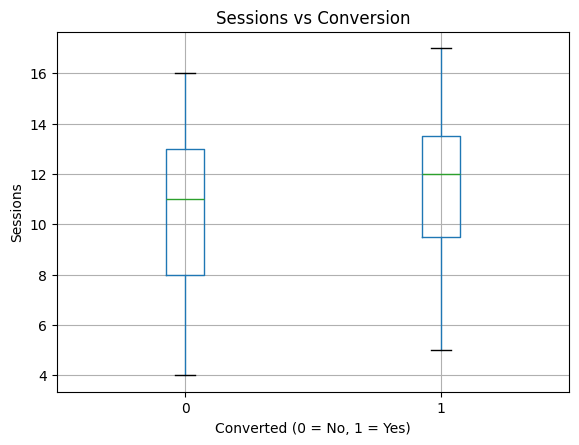

<Figure size 700x400 with 0 Axes>

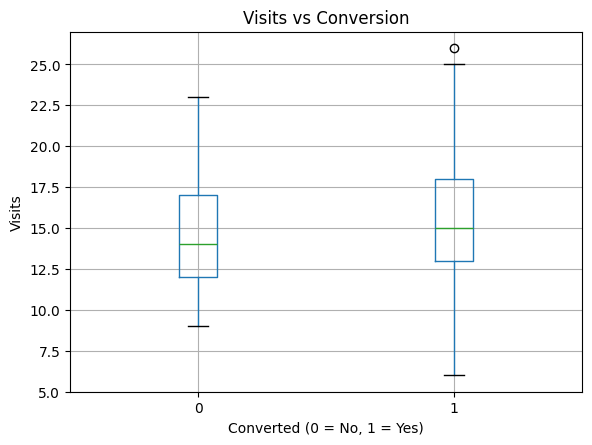

<Figure size 700x400 with 0 Axes>

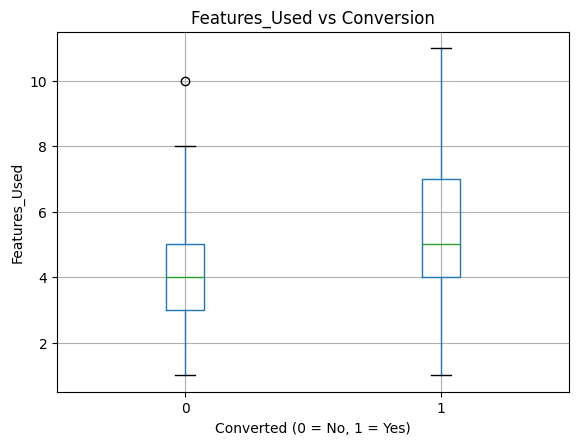

<Figure size 700x400 with 0 Axes>

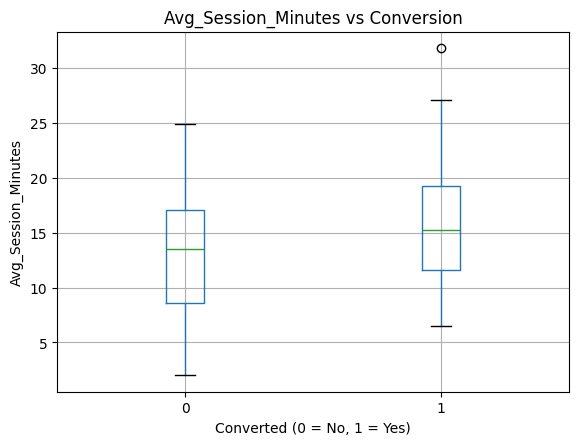

<Figure size 700x400 with 0 Axes>

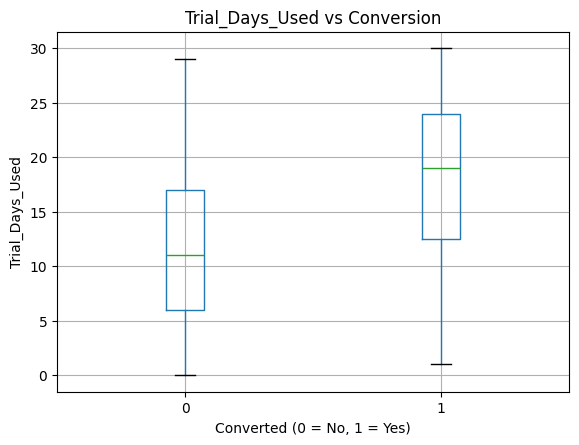

<Figure size 700x400 with 0 Axes>

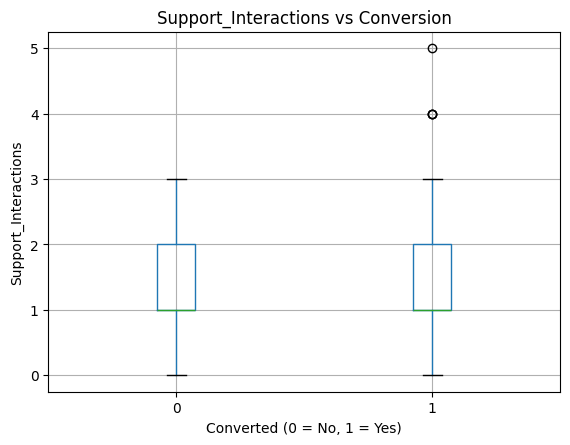

In [29]:
# Feature distributions by target
for col in eda_cols:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=col, by="Converted")
    plt.title(f"{col} vs Conversion")
    plt.suptitle("")
    plt.xlabel("Converted (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.show()


## 6. Feature Engineering

Create additional engagement features that may provide useful signals to the models.

Examples:
- Sessions per day since signup
- Visits per session
- Features used per session
- Engagement score


In [30]:
# Avoid division by zero
df["Sessions_Per_Day"] = df["Sessions"] / df["Days_Since_Signup"].clip(lower=1)
df["Visits_Per_Session"] = df["Visits"] / df["Sessions"].clip(lower=1)
df["Features_Per_Session"] = df["Features_Used"] / df["Sessions"].clip(lower=1)

# A simple composite engagement score
df["Engagement_Score"] = (
    df["Sessions"] +
    df["Visits"] +
    (df["Features_Used"] * 2) +
    df["Trial_Days_Used"]
)

display(df.head())


,User_ID,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Converted,Sessions_Per_Day,Visits_Per_Session,Features_Per_Session,Engagement_Score
0,U001,46,107,8,9,4,8.7,20,1,0,0.074766,1.125000,0.500000,45
1,U002,32,137,10,13,4,14.2,26,3,1,0.072993,1.300000,0.400000,57
2,U003,25,7,7,18,4,12.4,4,3,0,1.000000,2.571429,0.571429,37
3,U004,38,11,15,9,2,13.5,0,1,0,1.363636,0.600000,0.133333,28
4,U005,36,148,11,16,8,12.9,16,1,1,0.074324,1.454545,0.727273,59


## 7. Define Features and Target

**Target variable:** `Converted`

`User_ID` is excluded because it is only an identifier and has no predictive meaning.


In [31]:
target = "Converted"

feature_cols = [
    "Age",
    "Days_Since_Signup",
    "Sessions",
    "Visits",
    "Features_Used",
    "Avg_Session_Minutes",
    "Trial_Days_Used",
    "Support_Interactions",
    "Sessions_Per_Day",
    "Visits_Per_Session",
    "Features_Per_Session",
    "Engagement_Score"
]

X = df[feature_cols]
y = df[target]

print("Number of features:", X.shape[1])
print("Target distribution:")
print(y.value_counts())


Number of features: 12
Target distribution:
Converted
1    55
0    45
Name: count, dtype: int64


## 8. Train / Test Split

We use an **80/20 stratified split**.

Stratification helps maintain a similar proportion of converted and non-converted users in both sets.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 80
Testing samples: 20


## 9. Model 1 — Logistic Regression

Logistic Regression provides an interpretable baseline for binary classification.

Standardization is included in a pipeline because Logistic Regression generally benefits from features being on comparable scales.


In [33]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]


## 10. Model 2 — Decision Tree

A Decision Tree learns rule-based splits and can capture non-linear relationships.


In [34]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

tree_pred = decision_tree_model.predict(X_test)
tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]


## 11. Model 3 — Random Forest

Random Forest combines many decision trees to create an ensemble prediction and generally provides a robust baseline for tabular classification.


In [35]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]


## 12. Compare All Three Models

In [36]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, logistic_pred, logistic_prob),
    evaluate_model("Decision Tree", y_test, tree_pred, tree_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
])

display(results.round(4))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7,0.6923,0.8182,0.7500,0.7374
1,Decision Tree,0.6,0.6000,0.8182,0.6923,0.4949
2,Random Forest,0.8,0.7333,1.0000,0.8462,0.7677


## 13. Cross-Validation Comparison

With only 100 users, a single train/test split can produce unstable estimates. We therefore also use 5-fold stratified cross-validation for a more robust comparison.


In [37]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
display(cv_results.round(4))


,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.7758,0.1277
1,Decision Tree,0.6859,0.1481
2,Random Forest,0.7737,0.1384


## 14. Confusion Matrices

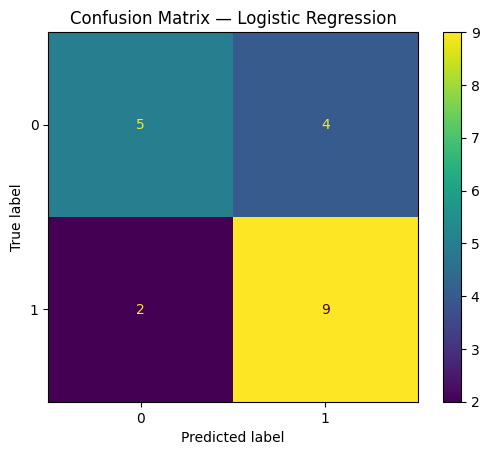

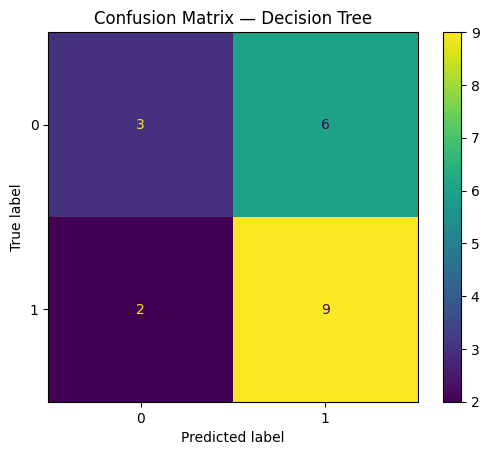

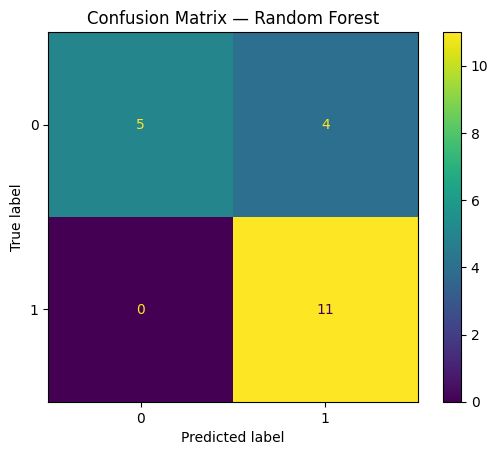

In [38]:
predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

for name, pred in predictions.items():
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


## 15. Classification Reports

In [39]:
for name, pred in predictions.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        pred,
        target_names=["Not Converted", "Converted"],
        zero_division=0
    ))


Logistic Regression
               precision    recall  f1-score   support

Not Converted       0.71      0.56      0.62         9
    Converted       0.69      0.82      0.75        11

     accuracy                           0.70        20
    macro avg       0.70      0.69      0.69        20
 weighted avg       0.70      0.70      0.69        20

Decision Tree
               precision    recall  f1-score   support

Not Converted       0.60      0.33      0.43         9
    Converted       0.60      0.82      0.69        11

     accuracy                           0.60        20
    macro avg       0.60      0.58      0.56        20
 weighted avg       0.60      0.60      0.57        20

Random Forest
               precision    recall  f1-score   support

Not Converted       1.00      0.56      0.71         9
    Converted       0.73      1.00      0.85        11

     accuracy                           0.80        20
    macro avg       0.87      0.78      0.78        20
 weighted

## 16. ROC Curve Comparison

<Figure size 800x600 with 0 Axes>

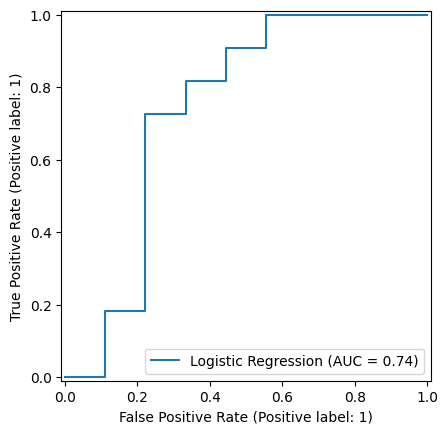

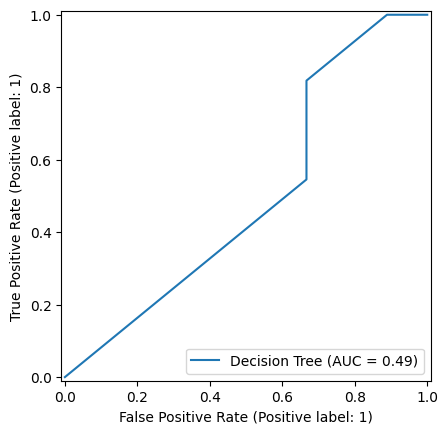

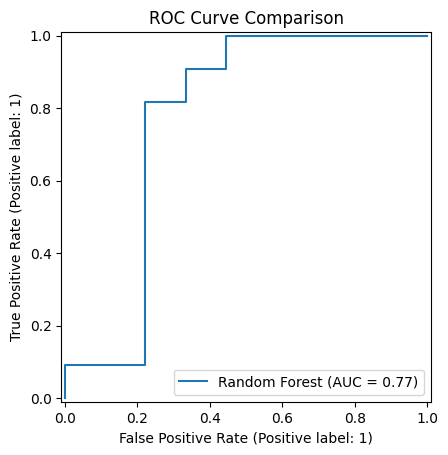

In [40]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, logistic_prob, name="Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_test, tree_prob, name="Decision Tree"
)
RocCurveDisplay.from_predictions(
    y_test, rf_prob, name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()


## 17. Feature Importance — Random Forest

Random Forest provides a useful view of which input features contributed most to its predictions.

**Important:** feature importance shows association with the model's predictions; it does not prove that a feature causes conversion.


,Feature,Importance
11,Engagement_Score,0.216645
6,Trial_Days_Used,0.135702
5,Avg_Session_Minutes,0.089223
10,Features_Per_Session,0.087251
4,Features_Used,0.073322
8,Sessions_Per_Day,0.070429
9,Visits_Per_Session,0.061813
1,Days_Since_Signup,0.061610
0,Age,0.061195
2,Sessions,0.057503


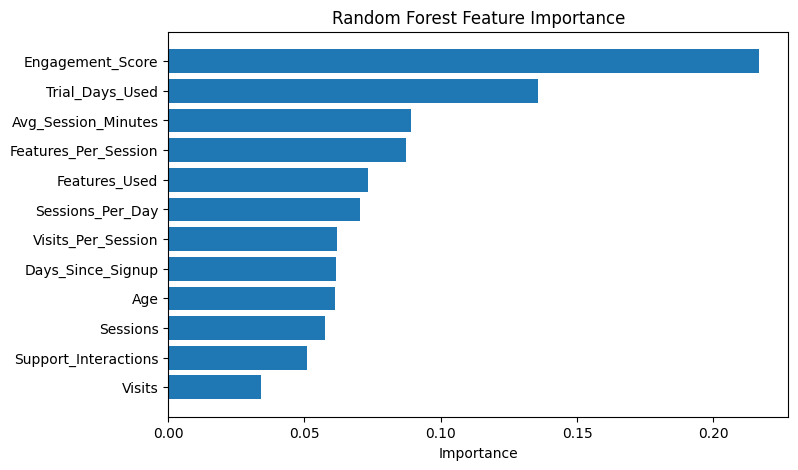

In [41]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()


## 18. Hyperparameter Tuning — Random Forest

We tune the Random Forest using cross-validation.

The goal is not simply to maximize one test-set metric, but to find a configuration that generalizes better.


In [42]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation ROC-AUC:", round(grid_search.best_score_, 4))


Best parameters:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation ROC-AUC: 0.7658


## 19. Evaluate Tuned Random Forest

In [43]:
tuned_rf = grid_search.best_estimator_

tuned_rf_pred = tuned_rf.predict(X_test)
tuned_rf_prob = tuned_rf.predict_proba(X_test)[:, 1]

tuned_result = pd.DataFrame([
    evaluate_model(
        "Tuned Random Forest",
        y_test,
        tuned_rf_pred,
        tuned_rf_prob
    )
])

display(tuned_result.round(4))

print(classification_report(
    y_test,
    tuned_rf_pred,
    target_names=["Not Converted", "Converted"],
    zero_division=0
))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.75,0.7143,0.9091,0.8,0.6869


               precision    recall  f1-score   support

Not Converted       0.83      0.56      0.67         9
    Converted       0.71      0.91      0.80        11

     accuracy                           0.75        20
    macro avg       0.77      0.73      0.73        20
 weighted avg       0.77      0.75      0.74        20



## 20. Final Model and Conversion Probability

For a real deployment, the final model should be selected based on the business objective and validation evidence.

The model below demonstrates how to produce a **conversion probability** for each test user.


In [44]:
# Demonstration using the tuned Random Forest
final_model = tuned_rf

conversion_probability = final_model.predict_proba(X_test)[:, 1]

prediction_output = X_test.copy()
prediction_output["Actual_Converted"] = y_test.values
prediction_output["Conversion_Probability"] = conversion_probability
prediction_output["Predicted_Converted"] = (
    conversion_probability >= 0.50
).astype(int)

prediction_output = prediction_output.sort_values(
    "Conversion_Probability",
    ascending=False
)

display(prediction_output.head(10))


,Age,Days_Since_Signup,Sessions,Visits,Features_Used,Avg_Session_Minutes,Trial_Days_Used,Support_Interactions,Sessions_Per_Day,Visits_Per_Session,Features_Per_Session,Engagement_Score,Actual_Converted,Conversion_Probability,Predicted_Converted
85,22,151,14,17,6,17.1,29,1,0.092715,1.214286,0.428571,72,0,0.814434,1
98,44,154,13,12,5,13.2,20,0,0.084416,0.923077,0.384615,55,0,0.792423,1
42,25,127,10,14,6,19.6,20,0,0.078740,1.400000,0.600000,56,1,0.790747,1
31,26,140,11,15,6,20.8,22,2,0.078571,1.363636,0.545455,60,1,0.790649,1
90,29,104,9,13,6,16.2,30,0,0.086538,1.444444,0.666667,64,1,0.779922,1
11,20,130,13,20,7,11.3,17,4,0.100000,1.538462,0.538462,64,1,0.760615,1
4,36,148,11,16,8,12.9,16,1,0.074324,1.454545,0.727273,59,1,0.734547,1
39,37,134,6,18,6,15.3,22,0,0.044776,3.000000,1.000000,58,1,0.721064,1
13,19,102,13,26,4,9.2,26,1,0.127451,2.000000,0.307692,73,1,0.714883,1
50,21,68,5,23,6,4.2,21,3,0.073529,4.600000,1.200000,61,0,0.713443,1


## 21. Business Interpretation

The final output can be used to segment free users by predicted conversion probability.

Example:

- High predicted probability → potentially prioritize for conversion messaging
- Medium probability → test personalized offers or onboarding
- Low probability → focus on engagement/onboarding rather than immediate conversion campaigns

These are **business actions to test**, not guarantees of user behavior.

### Important modeling note
This synthetic dataset is intended for learning and portfolio demonstration. With only 100 users, model metrics can vary substantially depending on the train/test split. A production system should use a much larger historical dataset, time-based validation where appropriate, leakage checks, calibration, monitoring, and periodic retraining.


# Final Project Summary

### Business Problem
Predict whether a free user will convert to a paid subscriber.

### Problem Type
Binary Classification

### Target Variable
`Converted`

### Models
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

### Final Output
A probability between 0 and 1 representing the model's estimated likelihood that a free user will convert.

### End-to-End Pipeline

```text
Raw User Data
      ↓
Data Cleaning
      ↓
EDA
      ↓
Feature Engineering
      ↓
Train / Test Split
      ↓
Logistic Regression
Decision Tree
Random Forest
      ↓
Model Comparison
      ↓
Hyperparameter Tuning
      ↓
Final Model
      ↓
Conversion Probability
```
